In [ ]:
# # Gymnasium 설치 (OpenAI Gym의 최신 버전)
# !pip install -q gymnasium[classic-control]
# !pip install -q pygame

In [1]:
# 기본 라이브러리 임포트
import numpy as np  # 수치 계산
import matplotlib.pyplot as plt  # 시각화
import gymnasium as gym  # 강화학습 환경
from collections import deque, defaultdict  # 자료구조
import random  # 랜덤 샘플링


# PyTorch (DQN용)
import torch  # PyTorch 메인
import torch.nn as nn  # 신경망
import torch.optim as optim  # 옵티마이저
import torch.nn.functional as F  # 활성화 함수


# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')


# 랜덤 시드 고정 (재현성)
def set_seed(seed=42):
    """모든 난수 생성기의 시드 고정"""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)


set_seed(42)


# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n 사용 디바이스: {device}")
print(f"   Gymnasium 버전: {gym.__version__}")
print(f"   PyTorch 버전: {torch.__version__}")


# 강화학습 핵심 개념
print("\n" + "=" * 60)
print("강화학습 핵심 개념")
print("=" * 60)
print("""
강화학습(Reinforcement Learning)은 Agent가 환경(Environment)과
상호작용하며 보상(Reward)을 최대화하는 방법을 학습하는 기법입니다.


┌─────────────────────────────────────────┐
│          Reinforcement Learning         │
│                                         │
│  ┌──────┐      Action        ┌──────┐   │
│  │Agent │ ────────────────>  │ Env  │   │
│  │      │ <────────────────  │      │   │
│  └──────┘   State, Reward    └──────┘   │
│                                         │
└─────────────────────────────────────────┘


주요 용어:
- State (상태): 환경의 현재 상황
- Action (행동): Agent가 취할 수 있는 행동
- Reward (보상): 행동에 대한 즉각적인 피드백
- Policy (정책): 상태에서 행동을 선택하는 전략
- Value Function (가치 함수): 상태 또는 행동의 장기적 가치
""")





 사용 디바이스: cuda
   Gymnasium 버전: 1.2.3
   PyTorch 버전: 2.10.0+cu130

강화학습 핵심 개념

강화학습(Reinforcement Learning)은 Agent가 환경(Environment)과
상호작용하며 보상(Reward)을 최대화하는 방법을 학습하는 기법입니다.


┌─────────────────────────────────────────┐
│          Reinforcement Learning         │
│                                         │
│  ┌──────┐      Action        ┌──────┐   │
│  │Agent │ ────────────────>  │ Env  │   │
│  │      │ <────────────────  │      │   │
│  └──────┘   State, Reward    └──────┘   │
│                                         │
└─────────────────────────────────────────┘


주요 용어:
- State (상태): 환경의 현재 상황
- Action (행동): Agent가 취할 수 있는 행동
- Reward (보상): 행동에 대한 즉각적인 피드백
- Policy (정책): 상태에서 행동을 선택하는 전략
- Value Function (가치 함수): 상태 또는 행동의 장기적 가치



In [3]:
# FrozenLake 환경 생성
print("\n FrozenLake-v1 환경:")
print("   목표: 얼어붙은 호수를 건너 목표 지점(G)에 도달")
print("   맵 구조:")
print("   S: 시작점 (Start)")
print("   F: 얼음 (Frozen) - 안전")
print("   H: 구멍 (Hole) - 빠지면 실패")
print("   G: 목표 (Goal)")


env_frozen = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')
# is_slippery=False: 결정론적 환경 (초급용)


print(f"\n   관찰 공간 (State): {env_frozen.observation_space}")
print(f"   행동 공간 (Action): {env_frozen.action_space}")
print(f"   - 0: 왼쪽 (Left)")
print(f"   - 1: 아래 (Down)")
print(f"   - 2: 오른쪽 (Right)")
print(f"   - 3: 위 (Up)")



 FrozenLake-v1 환경:
   목표: 얼어붙은 호수를 건너 목표 지점(G)에 도달
   맵 구조:
   S: 시작점 (Start)
   F: 얼음 (Frozen) - 안전
   H: 구멍 (Hole) - 빠지면 실패
   G: 목표 (Goal)

   관찰 공간 (State): Discrete(16)
   행동 공간 (Action): Discrete(4)
   - 0: 왼쪽 (Left)
   - 1: 아래 (Down)
   - 2: 오른쪽 (Right)
   - 3: 위 (Up)


In [5]:
state, info = env_frozen.reset(seed=42)

In [16]:
state

0

In [18]:
action = env_frozen.action_space.sample()

In [19]:
env_frozen.step(action)

(5, 0, True, False, {'prob': 1.0})

In [49]:
# random agent simulation

env_frozen = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')

state, info = env_frozen.reset(seed=42)
# state (초기 시작 상태)

total_reward = 0
steps = 0 # 수행 횟수

for step in range(20):
    action = env_frozen.action_space.sample()

    next_state, reward, terminated, truncated, info = env_frozen.step(action)
    # next_state 다음 상태, reward (성공1, 실패0) terminated 성공실패, truncated: 제한된 스텝수 강제 종료

    total_reward += reward
    steps += 1

    print(f'    Step {step+1}: State={state} >>> Action={action} >>>'
          f'Next State={next_state}, Reward={reward}')
    
    if terminated or truncated:
        print(f'    Episode 종료! 총보상: {total_reward}, steps:{step}')
        break

    state = next_state

env_frozen.close()

    Step 1: State=0 >>> Action=2 >>>Next State=1, Reward=0
    Step 2: State=1 >>> Action=1 >>>Next State=5, Reward=0
    Episode 종료! 총보상: 0, steps:1


In [50]:
# CartPole 환경 확인
print("\nCartPole-v1 환경:")
print("   목표: 막대를 수직으로 세운 채로 유지")
print("   상태: [위치, 속도, 각도, 각속도]")
print("   행동: 0=왼쪽, 1=오른쪽")
print("   보상: 매 스텝마다 +1 (최대 500)")


env_cart = gym.make('CartPole-v1', render_mode='rgb_array')
print(f"\n   관찰 공간: {env_cart.observation_space}")
print(f"   행동 공간: {env_cart.action_space}")
env_cart.close()


CartPole-v1 환경:
   목표: 막대를 수직으로 세운 채로 유지
   상태: [위치, 속도, 각도, 각속도]
   행동: 0=왼쪽, 1=오른쪽
   보상: 매 스텝마다 +1 (최대 500)

   관찰 공간: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
   행동 공간: Discrete(2)


In [51]:
# FrozenLake Q-learning

print("\n Q-learning 개념:")
print("""
Q-learning은 모델 없이(Model-free) 최적 정책을 학습하는 알고리즘입니다.


Q-value 업데이트 공식:
Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]


- r (reward) : 즉각적인 보상
- α (alpha): 학습률 (Learning Rate)
- γ (gamma): 할인율 (Discount Factor)
- ε (epsilon): 탐험 비율 (Exploration Rate)
""")




 Q-learning 개념:

Q-learning은 모델 없이(Model-free) 최적 정책을 학습하는 알고리즘입니다.


Q-value 업데이트 공식:
Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]


- r (reward) : 즉각적인 보상
- α (alpha): 학습률 (Learning Rate)
- γ (gamma): 할인율 (Discount Factor)
- ε (epsilon): 탐험 비율 (Exploration Rate)



In [3]:
# Q-learning Agent 클래스
class QLearningAgent:
    """
    Q-learning 에이전트
    테이블 기반으로 Q-value를 저장하고 업데이트
    이 agent 각 (상태-행동, state-action) 쌍 >> Q-value 를 2차원 배열 테이블 형태로 저장
    """
    def __init__(self, n_states, n_actions, learning_rate=0.1,
                 discount_factor=0.99, epsilon=1.0, epsilon_decay=0.995,
                 epsilon_min=0.01):
        """
        Args:
            n_states: 상태 개수
            n_actions: 행동 개수
            learning_rate: 학습률 (α)
            discount_factor: 할인율 (γ)
            epsilon: 초기 탐험 비율 (ε)
            epsilon_decay: ε 감소율
            epsilon_min: 최소 ε
        """
        self.n_states = n_states
        self.n_actions = n_actions
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min


        # Q-table 초기화 (모든 값을 0으로)
        self.q_table = np.zeros((n_states, n_actions))


    def get_action(self, state):
        """
        ε-greedy 정책으로 행동 선택
        Args:
            state: 현재 상태
        Returns:
            action: 선택된 행동
        """
        # 탐험(Exploration): 랜덤 행동
        if np.random.random() < self.epsilon:
            # random.random() >> [0,1] 무작위로(임의의) 수 하나 뽑기
            return np.random.randint(self.n_actions)
        
        # 활용(Exploitation): 최고 Q-value 행동
        else:
            return np.argmax(self.q_table[state])
            # q table에서 가장 값이 큰 행동(현재까지 있는 선택지에서 가장 좋아보이는 행동) 선택


    def update(self, state, action, reward, next_state, done):
        """
        Q-value 업데이트
        Args:
            state: 현재 상태
            action: 수행한 행동
            reward: 받은 보상
            next_state: 다음 상태
            done: 에피소드 종료 여부
        """
        # 현재 Q-value
        current_q = self.q_table[state, action]


        # TD(Time Difference) Target 계산
        if done:   # 에피소드가 종료
            target = reward
            # 종료 상태는 미래 보상 없음
            # 지금 받는 reward 만 target(목표) 됨
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])




        # Q-value 업데이트 (TD Error 기반)
        td_error = target - current_q
        # 목표(target) - 현재 값(current_q)
        self.q_table[state, action] += self.lr * td_error
        # td_error (시간차 오차)에 학습률(lr) 곱해서 기존 q값에 더해줌
        # >> 점점 더 좋은 값으로 수렴


    def decay_epsilon(self):
        """ε 감소 (탐험 비율 줄이기)"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        # epsilon이 epsilon_min보다 너무 작아지지 않게 하기 위해서 max() 써서 epsilon 업데이트 함


# FrozenLake Q-learning 학습
print("\n FrozenLake Q-learning 학습 시작:")



 FrozenLake Q-learning 학습 시작:


In [4]:
# 환경 및 에이전트 생성
env = gym.make('FrozenLake-v1', is_slippery=False, render_mode=None)
agent = QLearningAgent(
    n_states= env.observation_space.n,
    n_actions= env.action_space.n,
    learning_rate= 0.1,
    discount_factor=0.99,
    epsilon=1.0,
    epsilon_decay=0.9995,
    epsilon_min=0.01
)

n_episodes = 10000 # (2000번 게임 다시 시작하면서 학습)
max_steps = 100 # episode 당 최대 스텝(한게임당 100번 움직일 수 있음)

rewards_history = []
success_history = []

for episode in range(n_episodes):
    state, info = env.reset()
    episode_reward = 0

    for step in range(max_steps):
        # 행동 선택
        action = agent.get_action(state)

        # 환경에서 행동 수행
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-value update
        agent.update(state, action, reward, next_state, done)

        episode_reward += reward
        state = next_state

        if done:
            break

    # epsilon 감소
    agent.decay_epsilon()

    rewards_history.append(episode_reward)
    success_history.append(1 if episode_reward > 0 else 0)

    # 200 episode 마다 진행 상황 출력
    if (episode+1) % 200 == 0:
        avg_reward = np.mean(rewards_history[-100:])
        success_rate = np.mean(success_history[-100:]) * 100
        print(f'    Episode {episode+1}/{n_episodes} - '
              f'Avg.Reward: {avg_reward:.3f}, '
              f'Success Rate: {success_rate:.1f}', 
              f'epsilon: {agent.epsilon:.3f}')

env.close()

    Episode 200/10000 - Avg.Reward: 0.050, Success Rate: 5.0 epsilon: 0.905
    Episode 400/10000 - Avg.Reward: 0.040, Success Rate: 4.0 epsilon: 0.819
    Episode 600/10000 - Avg.Reward: 0.130, Success Rate: 13.0 epsilon: 0.741
    Episode 800/10000 - Avg.Reward: 0.200, Success Rate: 20.0 epsilon: 0.670
    Episode 1000/10000 - Avg.Reward: 0.260, Success Rate: 26.0 epsilon: 0.606
    Episode 1200/10000 - Avg.Reward: 0.290, Success Rate: 29.0 epsilon: 0.549
    Episode 1400/10000 - Avg.Reward: 0.310, Success Rate: 31.0 epsilon: 0.496
    Episode 1600/10000 - Avg.Reward: 0.420, Success Rate: 42.0 epsilon: 0.449
    Episode 1800/10000 - Avg.Reward: 0.610, Success Rate: 61.0 epsilon: 0.406
    Episode 2000/10000 - Avg.Reward: 0.590, Success Rate: 59.0 epsilon: 0.368
    Episode 2200/10000 - Avg.Reward: 0.620, Success Rate: 62.0 epsilon: 0.333
    Episode 2400/10000 - Avg.Reward: 0.590, Success Rate: 59.0 epsilon: 0.301
    Episode 2600/10000 - Avg.Reward: 0.670, Success Rate: 67.0 epsilon


 학습된 Q-table (처음 8개 상태):
[[0.94148015 0.95099005 0.95099001 0.94148015]
 [0.94148015 0.         0.96059601 0.94256842]
 [0.89624397 0.970299   0.61835562 0.80593173]
 [0.82925047 0.         0.20277842 0.1619783 ]
 [0.95099005 0.96059601 0.         0.94148015]
 [0.         0.         0.         0.        ]
 [0.         0.9801     0.         0.81095266]
 [0.         0.         0.         0.        ]]


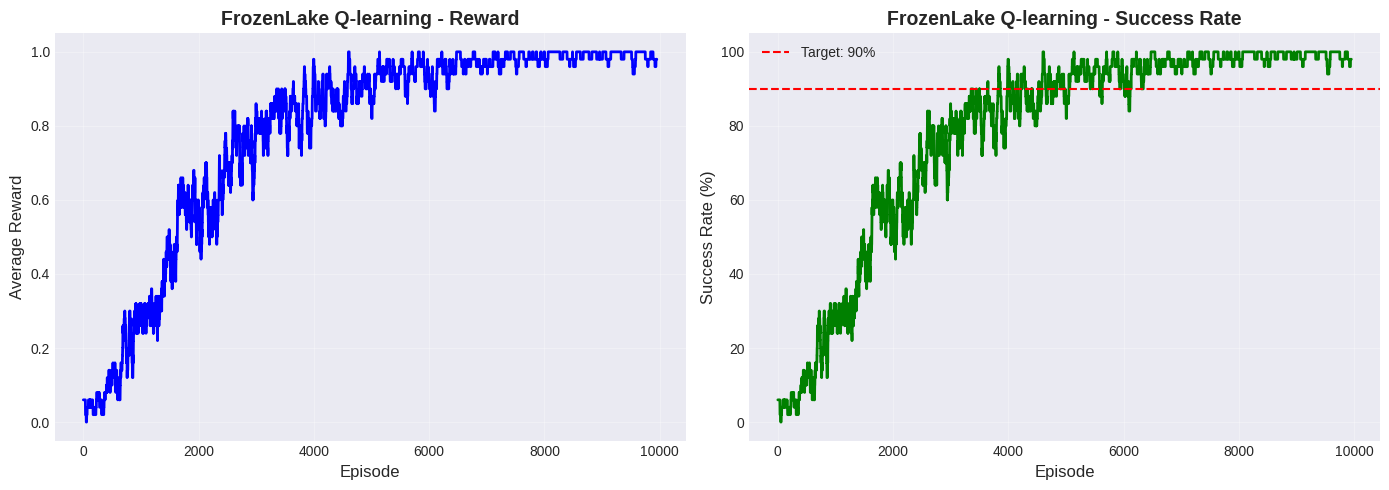

In [5]:
print("\n 학습된 Q-table (처음 8개 상태):")
print(agent.q_table[:8])


# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# 보상 그래프
window = 50
rewards_smooth = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
# np.convolve: 이동 평균
# mode='valid' 이동하는 window를 통해 유효한 성공률 확인 (최근 50번의 에피소드 중 평균 성공률)
# >> np.ones(window)/window를 통해 유효한 
axes[0].plot(rewards_smooth, linewidth=2, color='blue')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Average Reward', fontsize=12)
axes[0].set_title('FrozenLake Q-learning - Reward', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)


# 성공률 그래프
success_smooth = np.convolve(success_history, np.ones(window)/window, mode='valid') * 100
axes[1].plot(success_smooth, linewidth=2, color='green')
axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Success Rate (%)', fontsize=12)
axes[1].set_title('FrozenLake Q-learning - Success Rate', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=90, color='red', linestyle='--', label='Target: 90%')
axes[1].legend()


plt.tight_layout()
plt.savefig('frozenlake_qlearning_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
print("\nCartPole 환경 상세:")
print("""
CartPole-v1은 고전적인 제어 문제입니다.
카트 위에 막대가 달려있고, 카트를 좌우로 움직여
막대를 수직으로 세운 채 유지하는 것이 목표입니다.


상태 공간 (4차원):
- 위치 (Position): -4.8 ~ 4.8
- 속도 (Velocity): -∞ ~ ∞
- 각도 (Angle): -0.418 ~ 0.418 라디안 (약 ±24도)
- 각속도 (Angular Velocity): -∞ ~ ∞


행동 공간:
- 0: 왼쪽으로 힘 가하기
- 1: 오른쪽으로 힘 가하기


보상:
- 매 스텝마다 +1
- 막대가 일정 각도 이상 기울거나 카트가 화면 밖으로 나가면 종료
- 최대 500 스텝


종료 조건:
1. 막대 각도가 ±12도 초과
2. 카트 위치가 ±2.4 초과
3. 500 스텝 도달 (성공!)
""")


CartPole 환경 상세:

CartPole-v1은 고전적인 제어 문제입니다.
카트 위에 막대가 달려있고, 카트를 좌우로 움직여
막대를 수직으로 세운 채 유지하는 것이 목표입니다.


상태 공간 (4차원):
- 위치 (Position): -4.8 ~ 4.8
- 속도 (Velocity): -∞ ~ ∞
- 각도 (Angle): -0.418 ~ 0.418 라디안 (약 ±24도)
- 각속도 (Angular Velocity): -∞ ~ ∞


행동 공간:
- 0: 왼쪽으로 힘 가하기
- 1: 오른쪽으로 힘 가하기


보상:
- 매 스텝마다 +1
- 막대가 일정 각도 이상 기울거나 카트가 화면 밖으로 나가면 종료
- 최대 500 스텝


종료 조건:
1. 막대 각도가 ±12도 초과
2. 카트 위치가 ±2.4 초과
3. 500 스텝 도달 (성공!)



In [7]:
env = gym.make('CartPole-v1', render_mode=None)
state, inof = env.reset(seed=42)

state

array([ 0.0273956 , -0.00611216,  0.03585979,  0.0197368 ], dtype=float32)

In [8]:
episode_rewards = []

for episode in range(5):
    state, info = env.reset()
    episode_reward = 0

    for step in range(500):
        action = env.action_space.sample()
        state, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        if terminated or truncated:
            break

    episode_rewards.append(episode_reward)
    print(f'    Episode {episode+1}: Reward={episode_reward}')

print(f'    평균 보상: {np.mean(episode_rewards)}')
env.close()


    Episode 1: Reward=25.0
    Episode 2: Reward=29.0
    Episode 3: Reward=41.0
    Episode 4: Reward=22.0
    Episode 5: Reward=25.0
    평균 보상: 28.4


In [9]:
print("\nDQN 개념:")
print("""
DQN은 Q-learning을 신경망으로 확장한 알고리즘입니다.


핵심 아이디어:
1. Q-table 대신 신경망으로 Q-value 근사
2. Experience Replay: 과거 경험을 버퍼에 저장하고 랜덤 샘플링
3. Target Network: 안정적인 학습을 위해 타겟 네트워크 사용


DQN 구조:
┌─────────────────────────────────────────┐
│  State → [NN] → Q-values for all actions│
│                                         │
│  ex) [0.5, 1.2, 0.8] → Choose action 1  │
└─────────────────────────────────────────┘
""")




DQN 개념:

DQN은 Q-learning을 신경망으로 확장한 알고리즘입니다.


핵심 아이디어:
1. Q-table 대신 신경망으로 Q-value 근사
2. Experience Replay: 과거 경험을 버퍼에 저장하고 랜덤 샘플링
3. Target Network: 안정적인 학습을 위해 타겟 네트워크 사용


DQN 구조:
┌─────────────────────────────────────────┐
│  State → [NN] → Q-values for all actions│
│                                         │
│  ex) [0.5, 1.2, 0.8] → Choose action 1  │
└─────────────────────────────────────────┘



In [10]:
# DQN 신경망 정의
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()

        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
    
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        q_values = self.fc3(x)
        return q_values

In [11]:
sample_net = DQN(state_dim=4, action_dim=2, hidden_dim=16)
print(sample_net)

DQN(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=2, bias=True)
)


In [12]:
total_params = sum(p.numel() for p in sample_net.parameters())
total_params

386

In [13]:
random.sample([1,2,3,4], 2)

[1, 4]

In [14]:
# 경험 재생 버퍼 Experience Replay Buffer
# >> 과거 경험 저장 >> 랜덤하게 샘플링

class ReplayBuffer:
    def __init__(self, capacity):
        # capacity(최대 기억 용량) 버퍼 최대 크기
        self.buffer = deque(maxlen=capacity) # 최대 크기 제한
        # deque(): 꽉 차면 제일 오래된 기억부터 자동으로 지워짐

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size) # self.buffer에서 batch_size만큼 뽑음

        states = torch.FloatTensor([t[0] for t in batch])
        actions = torch.LongTensor([t[1] for t in batch])
        rewards = torch.FloatTensor([t[2] for t in batch])
        next_states = torch.FloatTensor([t[3] for t in batch])
        dones = torch.FloatTensor([t[4] for t in batch])

        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)

In [30]:
# 섹션 6: CartPole DQN 학습


# DQN Agent 클래스
class DQNAgent:
    """
    DQN 에이전트
    네트워크 학습 및 행동 선택 담당
    """
    def __init__(self, state_dim, action_dim, hidden_dim=128,
                 lr=0.001, gamma=0.99, epsilon=1.0, epsilon_decay=0.995,
                 epsilon_min=0.01, buffer_size=10000, batch_size=64):
        """
        Args:
            state_dim: 상태 차원
            action_dim: 행동 개수
            hidden_dim: 은닉층 크기
            lr: 학습률
            gamma: 할인율
            epsilon: 초기 탐험 비율
            epsilon_decay: ε 감소율
            epsilon_min: 최소 ε
            buffer_size: Replay Buffer 크기
            batch_size: 미니배치 크기
        """
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.batch_size = batch_size


        # Q-Network (학습용)
        self.q_network = DQN(state_dim, action_dim, hidden_dim).to(device)
        # Target Network (타겟 계산용) : 가끔씩만 업데이트 해야 함
        self.target_network = DQN(state_dim, action_dim, hidden_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()  # 평가 모드


        # 옵티마이저 및 손실 함수
        self.optimizer = optim.AdamW(self.q_network.parameters(), lr=lr, amsgrad=True)
        self.loss_fn = nn.MSELoss()


        # Replay Buffer
        self.memory = ReplayBuffer(buffer_size)


    def get_action(self, state):
        """
        ε-greedy 정책으로 행동 선택
        Args:
            state: 현재 상태
        Returns:
            action: 선택된 행동
        """
        # 탐험
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)


        # 활용
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.q_network(state_tensor)
            action = q_values.argmax().item()
        return action


    def train(self):
        """
        미니배치 학습
        Returns:
            loss: 학습 손실
        """
        # 버퍼에 충분한 데이터가 없으면 학습 안함
        if len(self.memory) < self.batch_size:
            return 0.0


        # 미니배치 샘플링
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        states = states.to(device) # batch, 4
        actions = actions.to(device) # batch
        rewards = rewards.to(device) # batch
        next_states = next_states.to(device) # batch, 4
        dones = dones.to(device) # batch


        # 현재 Q-values
        current_q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        # actions.unsqueeze(1) (batch_size, 1)
        # >> q_network(states) 때문에 (batch_size, n_actions) >> (batch, 2)
        # gather(1, ...) : 열방향
        # gather(actions와 outputs끼리 매칭해서 매칭된 outpus에서 action로 인덱스를 매칭한 값)


        # 타겟 Q-values (Target Network 사용)
        with torch.no_grad():
            max_next_q_values = self.target_network(next_states).max(1)[0]
            # max(1)[0] : (batch_size, n_actions) 에서 1(열방향, n_actions) 에 대해 최대값 구하고 그 인덱스 구하기
            target_q_values = rewards + (1 - dones) * self.gamma * max_next_q_values


        # 손실 계산 및 역전파
        loss = self.loss_fn(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


        return loss.item()


    def update_target_network(self):
        """Target Network를 Q-Network로 업데이트"""
        self.target_network.load_state_dict(self.q_network.state_dict())


    def decay_epsilon(self):
        """ε 감소"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


In [16]:
outputs = torch.tensor([[0.12,0.6],[0.12,0.6],[0.12,0.6]])
actions = torch.tensor([0,1,1])
actions.unsqueeze(1).shape
outputs.gather(1,actions.unsqueeze(1)).squeeze(1)

tensor([0.1200, 0.6000, 0.6000])

In [33]:
env = gym.make("CartPole-v1", render_mode=None)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=128,
    lr=0.0004,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    buffer_size=10000,
    batch_size=128
)


In [34]:
# from IPython.utils.path import target_update

n_episodes = 600
target_update_freq = 50

rewards_history=[]
losses_history =[]
for episode in range(n_episodes):
    state, info = env.reset()
    episode_reward = 0
    episode_loss = 0
    steps = 0

    for step in range(500):
        action = agent.get_action(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.memory.push(state, action, reward, next_state, done)

        loss = agent.train()
        episode_loss += loss

        episode_reward += reward
        state = next_state
        steps += 1

        if done:
            break

    agent.decay_epsilon()

    if (episode + 1) % target_update_freq == 0:
        agent.update_target_network()
    
    rewards_history.append(episode_reward)
    losses_history.append(episode_loss / steps if steps>0 else 0)




    # 50 에피소드마다 진행상황 출력
    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(rewards_history[-50:])
        avg_loss = np.mean(losses_history[-50:])
        print(f"   Episode {episode+1}/{n_episodes} - "
            f"Avg Reward: {avg_reward:.1f}, "
            f"Avg Loss: {avg_loss:.4f}, "
            f"ε: {agent.epsilon:.3f}")


env.close()




# 최종 성능
final_avg_reward = np.mean(rewards_history[-50:])
print(f"\n최종 50 에피소드 평균 보상: {final_avg_reward:.1f}")
if final_avg_reward >= 450:
    print("    우수! CartPole을 성공적으로 해결했습니다!")
elif final_avg_reward >= 300:
    print("    양호! 더 학습하면 성능이 향상될 수 있습니다.")
else:
    print("    학습 중... 에피소드를 늘리면 성능이 향상됩니다.")




   Episode 50/600 - Avg Reward: 22.4, Avg Loss: 0.0119, ε: 0.778
   Episode 100/600 - Avg Reward: 18.8, Avg Loss: 0.0400, ε: 0.606
   Episode 150/600 - Avg Reward: 40.6, Avg Loss: 0.0567, ε: 0.471
   Episode 200/600 - Avg Reward: 82.7, Avg Loss: 0.0497, ε: 0.367
   Episode 250/600 - Avg Reward: 110.0, Avg Loss: 0.0464, ε: 0.286
   Episode 300/600 - Avg Reward: 125.6, Avg Loss: 0.0754, ε: 0.222
   Episode 350/600 - Avg Reward: 167.3, Avg Loss: 0.0605, ε: 0.173
   Episode 400/600 - Avg Reward: 253.3, Avg Loss: 0.0277, ε: 0.135
   Episode 450/600 - Avg Reward: 266.7, Avg Loss: 0.0552, ε: 0.105
   Episode 500/600 - Avg Reward: 144.6, Avg Loss: 0.0307, ε: 0.082
   Episode 550/600 - Avg Reward: 139.9, Avg Loss: 0.0394, ε: 0.063
   Episode 600/600 - Avg Reward: 139.4, Avg Loss: 0.0192, ε: 0.049

최종 50 에피소드 평균 보상: 139.4
    학습 중... 에피소드를 늘리면 성능이 향상됩니다.


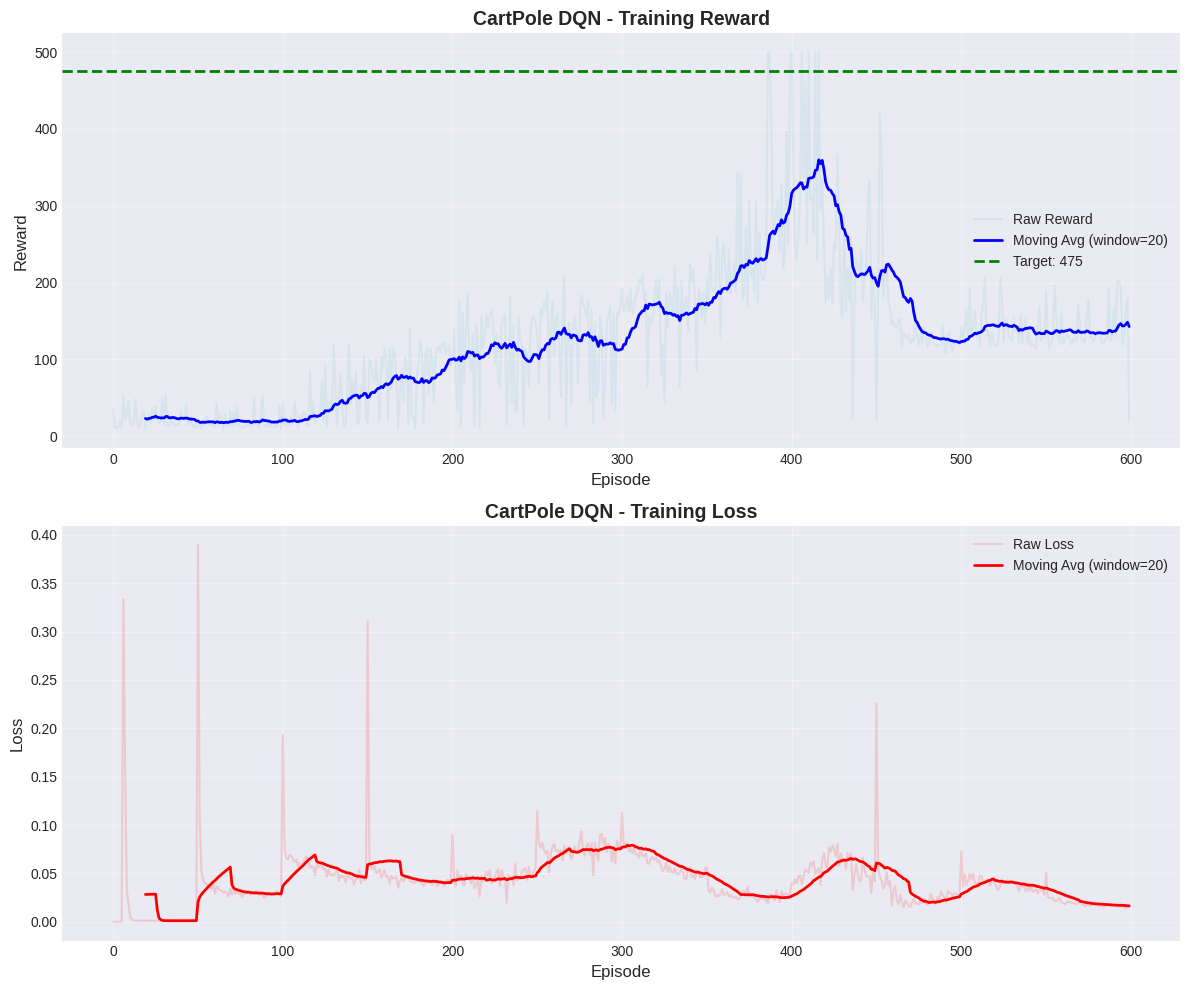


학습 결과 저장: cartpole_dqn_training.png


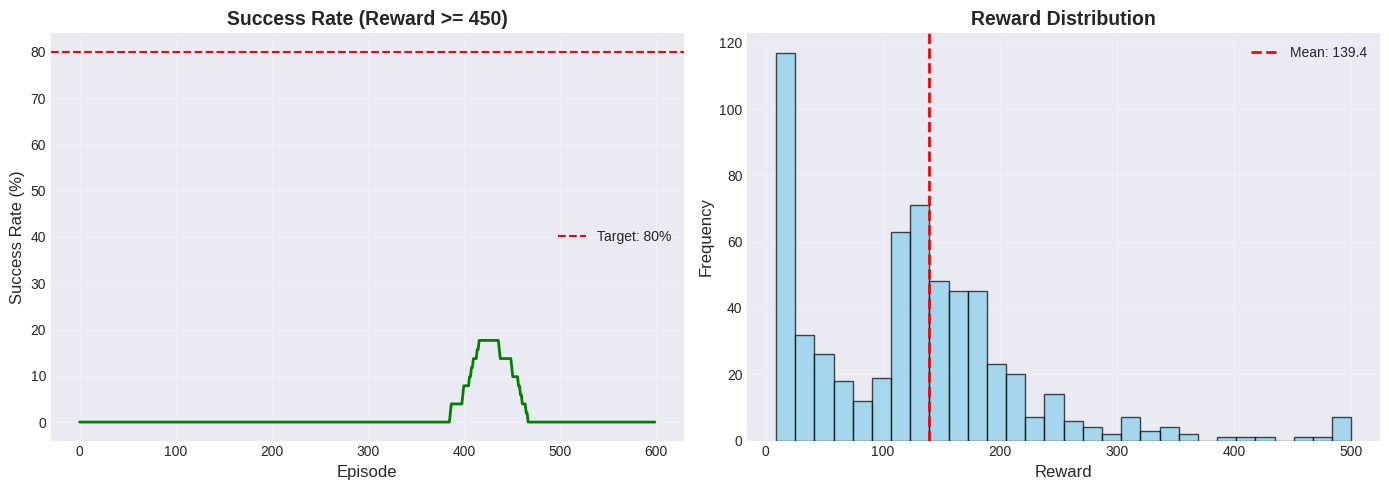

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))


# 보상 그래프
window = 20
rewards_smooth = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
axes[0].plot(rewards_history, alpha=0.3, color='lightblue', label='Raw Reward')
axes[0].plot(range(window-1, len(rewards_history)), rewards_smooth,
            linewidth=2, color='blue', label=f'Moving Avg (window={window})')
axes[0].axhline(y=475, color='green', linestyle='--', linewidth=2, label='Target: 475')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Reward', fontsize=12)
axes[0].set_title('CartPole DQN - Training Reward', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# 손실 그래프
loss_smooth = np.convolve(losses_history, np.ones(window)/window, mode='valid')
axes[1].plot(losses_history, alpha=0.3, color='lightcoral', label='Raw Loss')
axes[1].plot(range(window-1, len(losses_history)), loss_smooth,
            linewidth=2, color='red', label=f'Moving Avg (window={window})')
axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('CartPole DQN - Training Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('cartpole_dqn_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n학습 결과 저장: cartpole_dqn_training.png")


# 성능 통계 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# 에피소드별 성공률 (보상 >= 450)
success_threshold = 450
success_mask = np.array(rewards_history) >= success_threshold
success_rate = [np.mean(success_mask[max(0, i-50):i+1]) * 100
                for i in range(len(success_mask))]


axes[0].plot(success_rate, linewidth=2, color='green')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Success Rate (%)', fontsize=12)
axes[0].set_title('Success Rate (Reward >= 450)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=80, color='red', linestyle='--', label='Target: 80%')
axes[0].legend()


# 보상 분포 히스토그램
axes[1].hist(rewards_history, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=final_avg_reward, color='red', linestyle='--',
               linewidth=2, label=f'Mean: {final_avg_reward:.1f}')
axes[1].set_xlabel('Reward', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Reward Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('cartpole_dqn_stats.png', dpi=150, bbox_inches='tight')
plt.show()


In [37]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

env = gym.make("CartPole-v1")

# matplotlib 설정
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# GPU를 사용하는 경우
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)


In [38]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))


class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """transition 저장"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [39]:
class DQN(nn.Module):

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    # 최적화 중에 다음 행동을 결정하기 위해서 하나의 요소 또는 배치를 이용해 호촐됩니다.
    # ([[left0exp,right0exp]...]) 를 반환합니다.
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)


In [40]:
# BATCH_SIZE는 리플레이 버퍼에서 샘플링된 트랜지션의 수입니다.
# GAMMA는 이전 섹션에서 언급한 할인 계수입니다.
# EPS_START는 엡실론의 시작 값입니다.
# EPS_END는 엡실론의 최종 값입니다.
# EPS_DECAY는 엡실론의 지수 감쇠(exponential decay) 속도 제어하며, 높을수록 감쇠 속도가 느립니다.
# TAU는 목표 네트워크의 업데이트 속도입니다.
# LR은 ``AdamW`` 옵티마이저의 학습율(learning rate)입니다.

BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 2500
TAU = 0.005
LR = 3e-4

# gym 행동 공간에서 행동의 숫자를 얻습니다.
n_actions = env.action_space.n
# 상태 관측 횟수를 얻습니다.
state, info = env.reset()
n_observations = len(state)

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)


steps_done = 0


def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max (1)은 각 행의 가장 큰 열 값을 반환합니다.
            # 최대 결과의 두번째 열은 최대 요소의 주소값이므로,
            # 기대 보상이 더 큰 행동을 선택할 수 있습니다.
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)


episode_durations = []


def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # 100개의 에피소드 평균을 가져 와서 도표 그리기
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # 도표가 업데이트되도록 잠시 멈춤
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [41]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). 이것은 batch-array의 Transitions을 Transition의 batch-arrays로
    # 전환합니다.
    batch = Transition(*zip(*transitions))

    # 최종이 아닌 상태의 마스크를 계산하고 배치 요소를 연결합니다
    # (최종 상태는 시뮬레이션이 종료 된 이후의 상태)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Q(s_t, a) 계산 - 모델이 Q(s_t)를 계산하고, 취한 행동의 열을 선택합니다.
    # 이들은 policy_net에 따라 각 배치 상태에 대해 선택된 행동입니다.
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # 모든 다음 상태를 위한 V(s_{t+1}) 계산
    # non_final_next_states의 행동들에 대한 기대값은 "이전" target_net을 기반으로 계산됩니다.
    # max(1).values로 최고의 보상을 선택하십시오.
    # 이것은 마스크를 기반으로 병합되어 기대 상태 값을 갖거나 상태가 최종인 경우 0을 갖습니다.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # 기대 Q 값 계산
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Huber 손실 계산
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # 모델 최적화
    optimizer.zero_grad()
    loss.backward()
    # 변화도 클리핑 바꿔치기
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()


Complete


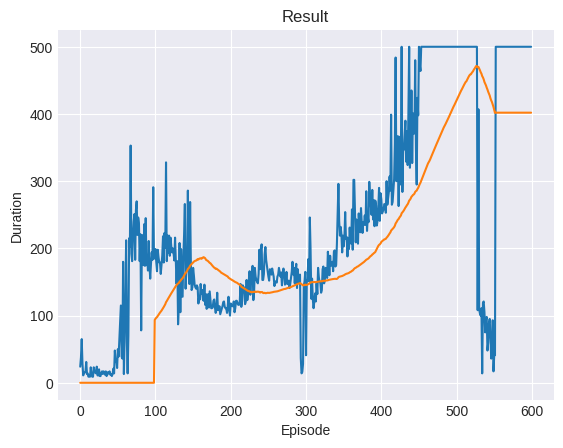

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [42]:
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 600
else:
    num_episodes = 50

for i_episode in range(num_episodes):
    # 환경과 상태 초기화
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        # 메모리에 변이 저장
        memory.push(state, action, next_state, reward)

        # 다음 상태로 이동
        state = next_state

        # (정책 네트워크에서) 최적화 한단계 수행
        optimize_model()

        # 목표 네트워크의 가중치를 소프트 업데이트
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations()
            break

print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()